In [6]:
#Installation of dependencies
! pip install hest scanpy anndata torch torchvision scikit-learn \
             matplotlib seaborn huggingface_hub tqdm pillow scipy h5py -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
#Imports and Configs
import os, glob, warnings
import numpy as np
import scipy.sparse as sp
import h5py
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import scanpy as sc
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from huggingface_hub import login, snapshot_download
from tqdm import tqdm

warnings.filterwarnings('ignore')
sc.settings.verbosity = 0
np.random.seed(42)
torch.manual_seed(42)

HF_TOKEN = 'hf**************************'
TASKS    = ['CCRCC', 'COAD']
DATA_DIR = './hest_bench_data'
N_GENES  = 50
N_PCA    = 256
BATCH    = 256

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
COLORS   = {'CCRCC': '#4C72B0', 'COAD': '#DD8452'}

login(token=HF_TOKEN, add_to_git_credential=False)
print(f' HuggingFace login OK | Device: {DEVICE}')

 HuggingFace login OK | Device: cuda


In [8]:
#Downloading hest-bench +exploring structure

os.makedirs(DATA_DIR, exist_ok=True)

snapshot_download(
    repo_id        = 'MahmoodLab/hest-bench',
    repo_type      = 'dataset',
    token          = HF_TOKEN,
    local_dir      = DATA_DIR,
    allow_patterns = [f'{t}/**' for t in TASKS],
)
print(' Download complete\n')

# Printing directory tree(3 levels deep)
for task in TASKS:
    td = os.path.join(DATA_DIR, task)
    if not os.path.exists(td):
        print(f'[WARN] {task} directory not found')
        continue
    print(f'{"="*46}\n📁 {task}/')
    for root, dirs, files in os.walk(td):
        depth = root.replace(td, '').count(os.sep)
        if depth > 2:
            continue
        indent = '  ' * depth
        print(f'{indent}📁 {os.path.basename(root)}/  [{len(files)} files]')
        for f in sorted(files)[:4]:
            print(f'{indent}    {f}')
    print()

Fetching 103 files:   0%|          | 0/103 [00:00<?, ?it/s]

 Download complete

📁 CCRCC/
📁 CCRCC/  [2 files]
    mean_50genes.json
    var_50genes.json
  📁 splits/  [12 files]
      test_0.csv
      test_1.csv
      test_2.csv
      test_3.csv
  📁 patches/  [24 files]
      INT1.h5
      INT10.h5
      INT11.h5
      INT12.h5
    📁 vis/  [24 files]
        INT1.png
        INT10.png
        INT11.png
        INT12.png
  📁 adata/  [24 files]
      INT1.h5ad
      INT10.h5ad
      INT11.h5ad
      INT12.h5ad

📁 COAD/
📁 COAD/  [1 files]
    var_50genes.json
  📁 patches_vis/  [4 files]
      TENX111.png
      TENX147.png
      TENX148.png
      TENX149.png
  📁 splits/  [4 files]
      test_0.csv
      test_1.csv
      train_0.csv
      train_1.csv
  📁 patches/  [4 files]
      TENX111.h5
      TENX147.h5
      TENX148.h5
      TENX149.h5
  📁 adata/  [4 files]
      TENX111.h5ad
      TENX147.h5ad
      TENX148.h5ad
      TENX149.h5ad




[CCRCC]  24 sample(s) found


  INT1: 1084 spots | 50 genes | 1084 patches | h5=True
  INT10: 1983 spots | 50 genes | 1983 patches | h5=True
  INT11: 1439 spots | 50 genes | 1439 patches | h5=True
  INT12: 1451 spots | 50 genes | 1451 patches | h5=True
  INT13: 4359 spots | 50 genes | 4359 patches | h5=True
  INT14: 4562 spots | 50 genes | 4562 patches | h5=True
  INT15: 4940 spots | 50 genes | 4940 patches | h5=True
  INT16: 3206 spots | 50 genes | 3206 patches | h5=True
  INT17: 3585 spots | 50 genes | 3585 patches | h5=True
  INT18: 4915 spots | 50 genes | 4915 patches | h5=True
  INT19: 4948 spots | 50 genes | 4948 patches | h5=True
  INT2: 2580 spots | 50 genes | 2580 patches | h5=True
  INT20: 4860 spots | 50 genes | 4860 patches | h5=True
  INT21: 4975 spots | 50 genes | 4975 patches | h5=True
  INT22: 3829 spots | 50 genes | 3829 patches | h5=True
  INT23: 4755 spots | 50 genes | 4755 patches | h5=True
  INT24: 4510 spots | 50 genes | 4510 patches | h5=True
  INT3: 2007 spots | 50 genes | 2007 patches | h5=

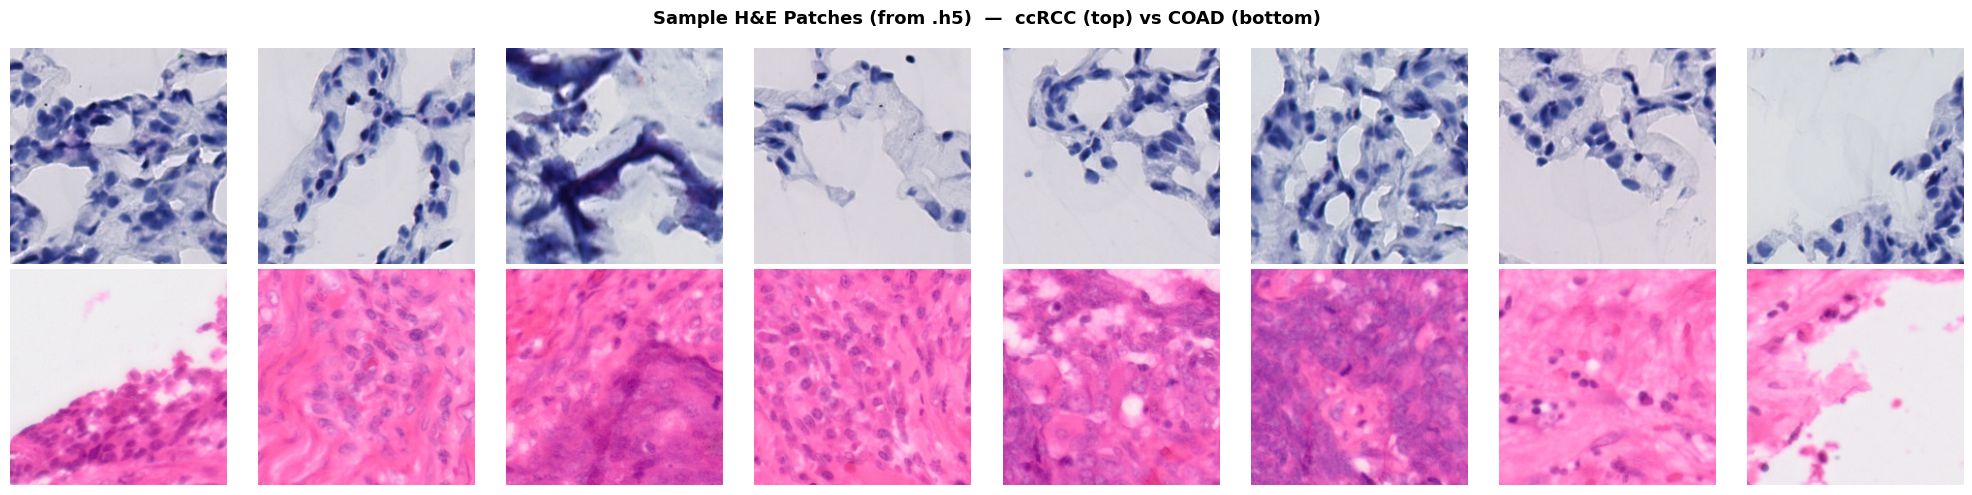

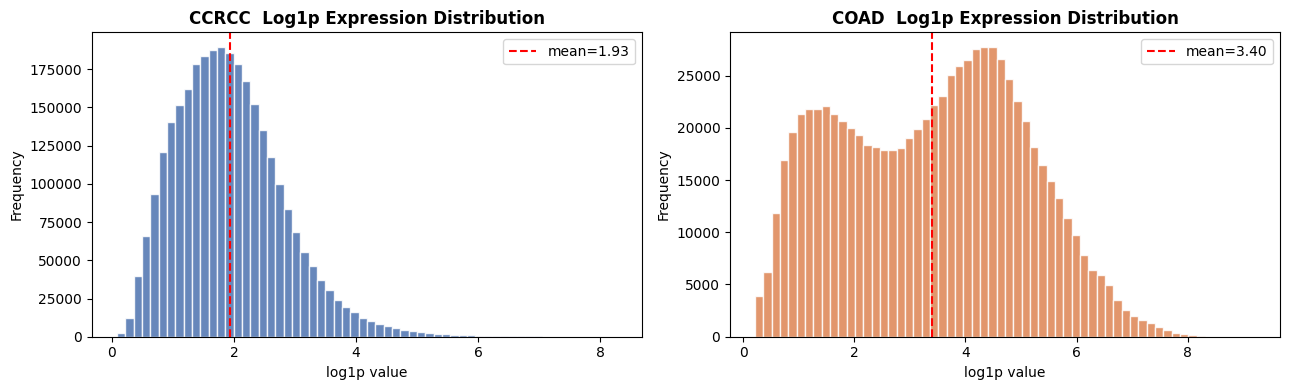

eda completed


In [9]:
#Data loading and eda

def load_and_preprocess(h5ad_path):
    adata = sc.read_h5ad(h5ad_path)
    X = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X, dtype=np.float32)
    if adata.n_vars > N_GENES:
        if X.max() > 20:
            sc.pp.normalize_total(adata, target_sum=1e4)
            sc.pp.log1p(adata)
            X = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X, dtype=np.float32)
        top_idx = np.argsort(np.var(X, axis=0))[-N_GENES:]
        adata = adata[:, top_idx].copy()
    return adata

def h5_patch_path(task_dir, sid):
    p = os.path.join(task_dir, 'patches', f'{sid}.h5')
    return p if os.path.isfile(p) else None

def inspect_h5(path):
    with h5py.File(path, 'r') as f:
        for k in f.keys():
            print(f'  key={k!r:20s}  shape={f[k].shape}  dtype={f[k].dtype}')

task_data = {}

for task in TASKS:
    td        = os.path.join(DATA_DIR, task)
    h5ad_dir  = os.path.join(td, 'adata')
    h5ad_list = sorted(glob.glob(os.path.join(h5ad_dir, '*.h5ad')))
    print(f'\n[{task}]  {len(h5ad_list)} sample(s) found')
    samples = {}
    for fp in h5ad_list:
        sid   = os.path.splitext(os.path.basename(fp))[0]
        adata = load_and_preprocess(fp)
        h5p   = h5_patch_path(td, sid)
        n_patches = 0
        if h5p:
            with h5py.File(h5p, 'r') as f:
                n_patches = f['img'].shape[0]
        print(f'  {sid}: {adata.n_obs} spots | {adata.n_vars} genes | '
              f'{n_patches} patches | h5={h5p is not None}')
        samples[sid] = {'adata': adata, 'h5_path': h5p}
    task_data[task] = samples

# Inspecting one h5 file per task
print('\n─ H5 patch file structure (one example per task) ─')
for task in TASKS:
    first_sid = next((s for s in task_data[task]
                      if task_data[task][s]['h5_path']), None)
    if first_sid:
        print(f'[{task}] {first_sid}')
        inspect_h5(task_data[task][first_sid]['h5_path'])

# ─ EDA 1: Showing sample patches from h5 
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Sample H&E Patches (from .h5)  —  ccRCC (top) vs COAD (bottom)',
             fontsize=13, fontweight='bold')
for row, task in enumerate(TASKS):
    first_sid = next((s for s in task_data[task]
                      if task_data[task][s]['h5_path']), None)
    patches_shown = []
    if first_sid:
        with h5py.File(task_data[task][first_sid]['h5_path'], 'r') as f:
            # sample 8 evenly-spaced patches so we see diverse tissue regions
            total   = f['img'].shape[0]
            indices = np.linspace(0, total - 1, 8, dtype=int)
            arr     = f['img'][indices]
            patches_shown = [arr[j] for j in range(len(arr))]
    for col in range(8):
        ax = axes[row, col]
        if col < len(patches_shown):
            p = patches_shown[col]
            if p.dtype != np.uint8:
                p = (p * 255).clip(0, 255).astype(np.uint8)
            ax.imshow(p)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(task, fontsize=10, fontweight='bold',
                          rotation=0, labelpad=40, va='center')
plt.tight_layout()
plt.savefig('eda_patches.png', dpi=110, bbox_inches='tight')
plt.show()

# ─ EDA 2: Gene expression distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, task in enumerate(TASKS):
    vals = np.concatenate([
        (s['adata'].X.toarray() if sp.issparse(s['adata'].X)
         else s['adata'].X).flatten()
        for s in task_data[task].values()
    ])
    nz = vals[vals > 0]
    axes[i].hist(nz, bins=60, color=COLORS[task], alpha=0.85, edgecolor='white')
    axes[i].axvline(nz.mean(), color='red', ls='--', lw=1.5,
                    label=f'mean={nz.mean():.2f}')
    axes[i].set_title(f'{task}  Log1p Expression Distribution', fontweight='bold')
    axes[i].set_xlabel('log1p value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
plt.tight_layout()
plt.savefig('eda_expression.png', dpi=110, bbox_inches='tight')
plt.show()
print('eda completed')

In [10]:
#ResNet50 embedding extraction with barcode-based spot alignment

class H5PatchDataset(Dataset):
    """
    Reads patches from h5. Returns (tensor, position_in_h5) pairs.
    Barcode alignment happens after extraction in extract_embeddings().
    """
    def __init__(self, h5_path, transform):
        self.h5_path   = h5_path
        self.transform = transform
        with h5py.File(h5_path, 'r') as f:
            self.length = f['img'].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, i):
        with h5py.File(self.h5_path, 'r') as f:
            patch = f['img'][i]          # (224, 224, 3) uint8
        if patch.dtype != np.uint8:
            patch = (patch * 255).clip(0, 255).astype(np.uint8)
        return self.transform(Image.fromarray(patch, mode='RGB')), i


TRANSFORM = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

_rn     = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
ENCODER = nn.Sequential(*list(_rn.children())[:-1]).to(DEVICE).eval()
print(f' ResNet50 loaded  |  Output dim: 2048  →  PCA  →  {N_PCA}')


@torch.no_grad()
def extract_embeddings(h5_path, adata):
    """
    Extract embeddings and align to adata via barcode matching.
    Returns (aligned_emb, filtered_adata) where rows correspond 1-to-1.
    """
    ds     = H5PatchDataset(h5_path, TRANSFORM)
    loader = DataLoader(ds, batch_size=BATCH, shuffle=False,
                        num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

    # Step 1: extracting all embeddings from h5 (one per patch row)
    all_emb = np.zeros((len(ds), 2048), dtype=np.float32)
    for imgs, idxs in tqdm(loader, leave=False, desc='  batches'):
        feats = ENCODER(imgs.to(DEVICE)).squeeze(-1).squeeze(-1).cpu().numpy()
        for feat, idx in zip(feats, idxs.numpy()):
            all_emb[idx] = feat

    # Step 2: then reading barcodes from h5 (shape: (n_patches, 1), dtype object)
    with h5py.File(h5_path, 'r') as f:
        raw = f['barcode'][:] 
    raw = raw.flatten()
    h5_barcodes = np.array([
        b.decode('utf-8') if isinstance(b, bytes) else str(b)
        for b in raw
    ])

    # Step 3: matching adata obs_names → h5 barcodes
    adata_barcodes = np.array(list(adata.obs_names))
    h5_bc_index    = {bc: i for i, bc in enumerate(h5_barcodes)}
    matched_rows   = []   # row indices into all_emb
    matched_adata  = []   # row indices into adata

    for ai, bc in enumerate(adata_barcodes):
        if bc in h5_bc_index:
            matched_rows.append(h5_bc_index[bc])
            matched_adata.append(ai)

    if len(matched_rows) == 0:
        # Fallback: positional truncation if barcodes don't match at all
        print('  [WARN] barcode match failed — falling back to positional align')
        n = min(len(ds), adata.n_obs)
        return all_emb[:n], adata[:n].copy()

    aligned_emb   = all_emb[matched_rows]
    aligned_adata = adata[matched_adata].copy()
    return aligned_emb, aligned_adata


for task in TASKS:
    print(f'\n[{task}] Extracting embeddings...')
    for sid, data in task_data[task].items():
        h5p = data['h5_path']
        if not h5p:
            print(f'  ⚠ {sid}: h5 patch file not found — skipping')
            continue
        emb, aligned_adata = extract_embeddings(h5p, data['adata'])
        data['emb']   = emb
        data['adata'] = aligned_adata
        print(f'  {sid}: {emb.shape[0]} matched spot-patch pairs')

print('\n Embedding extraction completed')

 ResNet50 loaded  |  Output dim: 2048  →  PCA  →  256

[CCRCC] Extracting embeddings...


  INT1: 1084 matched spot-patch pairs


  INT10: 1983 matched spot-patch pairs


  INT11: 1439 matched spot-patch pairs


  INT12: 1451 matched spot-patch pairs


...

  INT9: 1696 matched spot-patch pairs

[COAD] Extracting embeddings...


  TENX111: 5079 matched spot-patch pairs


  TENX147: 3417 matched spot-patch pairs


  TENX148: 3535 matched spot-patch pairs


  TENX149: 3620 matched spot-patch pairs

 Embedding extraction completed


In [11]:
#Leave-one-sample-out CV  + PCA 2048→256  + Ridge regression
def get_X(data):
    return data['emb']

def get_y(data):
    X = data['adata'].X
    return X.toarray() if sp.issparse(X) else np.array(X, dtype=np.float32)


results = {}

for task in TASKS:
    valid_sids = [s for s in task_data[task] if 'emb' in task_data[task][s]]
    print(f'\n{"="*52}\n[{task}]  Leave-one-sample-out CV  ({len(valid_sids)} folds)\n')

    if len(valid_sids) < 2:
        print(f'  ⚠ Need ≥2 samples for CV — skipping {task}')
        results[task] = {}
        continue

    fold_results = {}
    for test_sid in valid_sids:
        train_sids = [s for s in valid_sids if s != test_sid]

        X_train = np.vstack([get_X(task_data[task][s]) for s in train_sids])
        y_train = np.vstack([get_y(task_data[task][s]) for s in train_sids])
        X_test  = get_X(task_data[task][test_sid])
        y_test  = get_y(task_data[task][test_sid])

        # PCA fitted on train only — no data leakage
        pca      = PCA(n_components=min(N_PCA, X_train.shape[0]-1, X_train.shape[1]),
                       random_state=42)
        X_tr_pca = pca.fit_transform(X_train)
        X_te_pca = pca.transform(X_test)

        # Ridge: α = 100/(M×C)  exact HEST-Benchmark formula
        ridge = Ridge(alpha=100.0 / (N_PCA * N_GENES))
        ridge.fit(X_tr_pca, y_train)
        y_pred = ridge.predict(X_te_pca)

        gene_cors = [
            float(pearsonr(y_test[:, g], y_pred[:, g])[0])
            if not np.all(y_test[:, g] == y_test[0, g]) else 0.0
            for g in range(y_test.shape[1])
        ]
        mean_r = float(np.nanmean(gene_cors))

        fold_results[test_sid] = {
            'mean':       mean_r,
            'gene_cors':  gene_cors,
            'y_test':     y_test,
            'y_pred':     y_pred,
            'gene_names': list(task_data[task][test_sid]['adata'].var_names)
        }
        print(f'  Fold [{test_sid:>12}]   Pearson = {mean_r:.4f}')

    results[task] = fold_results

print('\n Training and evaluation completed')


[CCRCC]  Leave-one-sample-out CV  (24 folds)

  Fold [        INT1]   Pearson = 0.0280
  Fold [       INT10]   Pearson = 0.0312


  Fold [       INT11]   Pearson = 0.0662
  Fold [       INT12]   Pearson = 0.0410
  Fold [       INT13]   Pearson = 0.0352
  Fold [       INT14]   Pearson = 0.0479
  Fold [       INT15]   Pearson = 0.0116
  Fold [       INT16]   Pearson = 0.0782
  Fold [       INT17]   Pearson = 0.0280
  Fold [       INT18]   Pearson = -0.0075
  Fold [       INT19]   Pearson = 0.0500
  Fold [        INT2]   Pearson = 0.0335
  Fold [       INT20]   Pearson = -0.0176
  Fold [       INT21]   Pearson = 0.0843
  Fold [       INT22]   Pearson = -0.0119
  Fold [       INT23]   Pearson = 0.0221
  Fold [       INT24]   Pearson = 0.0126
  Fold [        INT3]   Pearson = 0.0308
  Fold [        INT4]   Pearson = 0.0583
  Fold [        INT5]   Pearson = 0.0261
  Fold [        INT6]   Pearson = 0.0452
  Fold [        INT7]   Pearson = -0.0053
  Fold [        INT8]   Pearson = 0.0409
  Fold [        INT9]   Pearson = 0.0351

[COAD]  Leave-one-sample-out CV  (4 folds)

  Fold [     TENX111]   Pearson = -0.0567
  Fold 

In [12]:
#Results summary table
PAPER_REF = {'CCRCC': 0.2231, 'COAD': 0.2528}

summary = {}
for task in TASKS:
    fold_means = [v['mean'] for v in results[task].values()]
    if fold_means:
        summary[task] = {'mean': np.mean(fold_means),
                         'std':  np.std(fold_means),
                         'folds': fold_means}
    else:
        summary[task] = {'mean': float('nan'), 'std': float('nan'), 'folds': []}

print(f'\n{"="*60}')
print(f'{"HEST-Benchmark Baseline Results":^60}')
print(f'{"Model: ResNet50(ImageNet) → PCA-256 → Ridge":^60}')
print(f'{"="*60}\n')
print(f'{"Task":<10} {"Folds":>5}  {"Ours (mean±std)":>18}  {"Paper Table 1":>14}  {"Δ":>8}')
print('─'*60)
for task in TASKS:
    m, s = summary[task]['mean'], summary[task]['std']
    p    = PAPER_REF[task]
    n    = len(summary[task]['folds'])
    delta = f'{m-p:+.4f}' if not np.isnan(m) else 'N/A'
    mstr  = f'{m:.4f} ± {s:.4f}' if not np.isnan(m) else 'N/A'
    print(f'{task:<10} {n:>5}  {mstr:>18}  {p:.4f}        {delta:>8}')
print('─'*60)

both_ok = all(not np.isnan(summary[t]['mean']) for t in TASKS)
if both_ok:
    gap = abs(summary['CCRCC']['mean'] - summary['COAD']['mean'])
    print(f'\nPerformance gap (|COAD − ccRCC|): {gap:.4f}')
    print(f'\n→ Identical pipeline, different accuracy per cancer type.')


              HEST-Benchmark Baseline Results               
        Model: ResNet50(ImageNet) → PCA-256 → Ridge         

Task       Folds     Ours (mean±std)   Paper Table 1         Δ
────────────────────────────────────────────────────────────
CCRCC         24     0.0318 ± 0.0258  0.2231         -0.1913
COAD           4     0.0514 ± 0.0672  0.2528         -0.2014
────────────────────────────────────────────────────────────

Performance gap (|COAD − ccRCC|): 0.0196

→ Identical pipeline, different accuracy per cancer type.


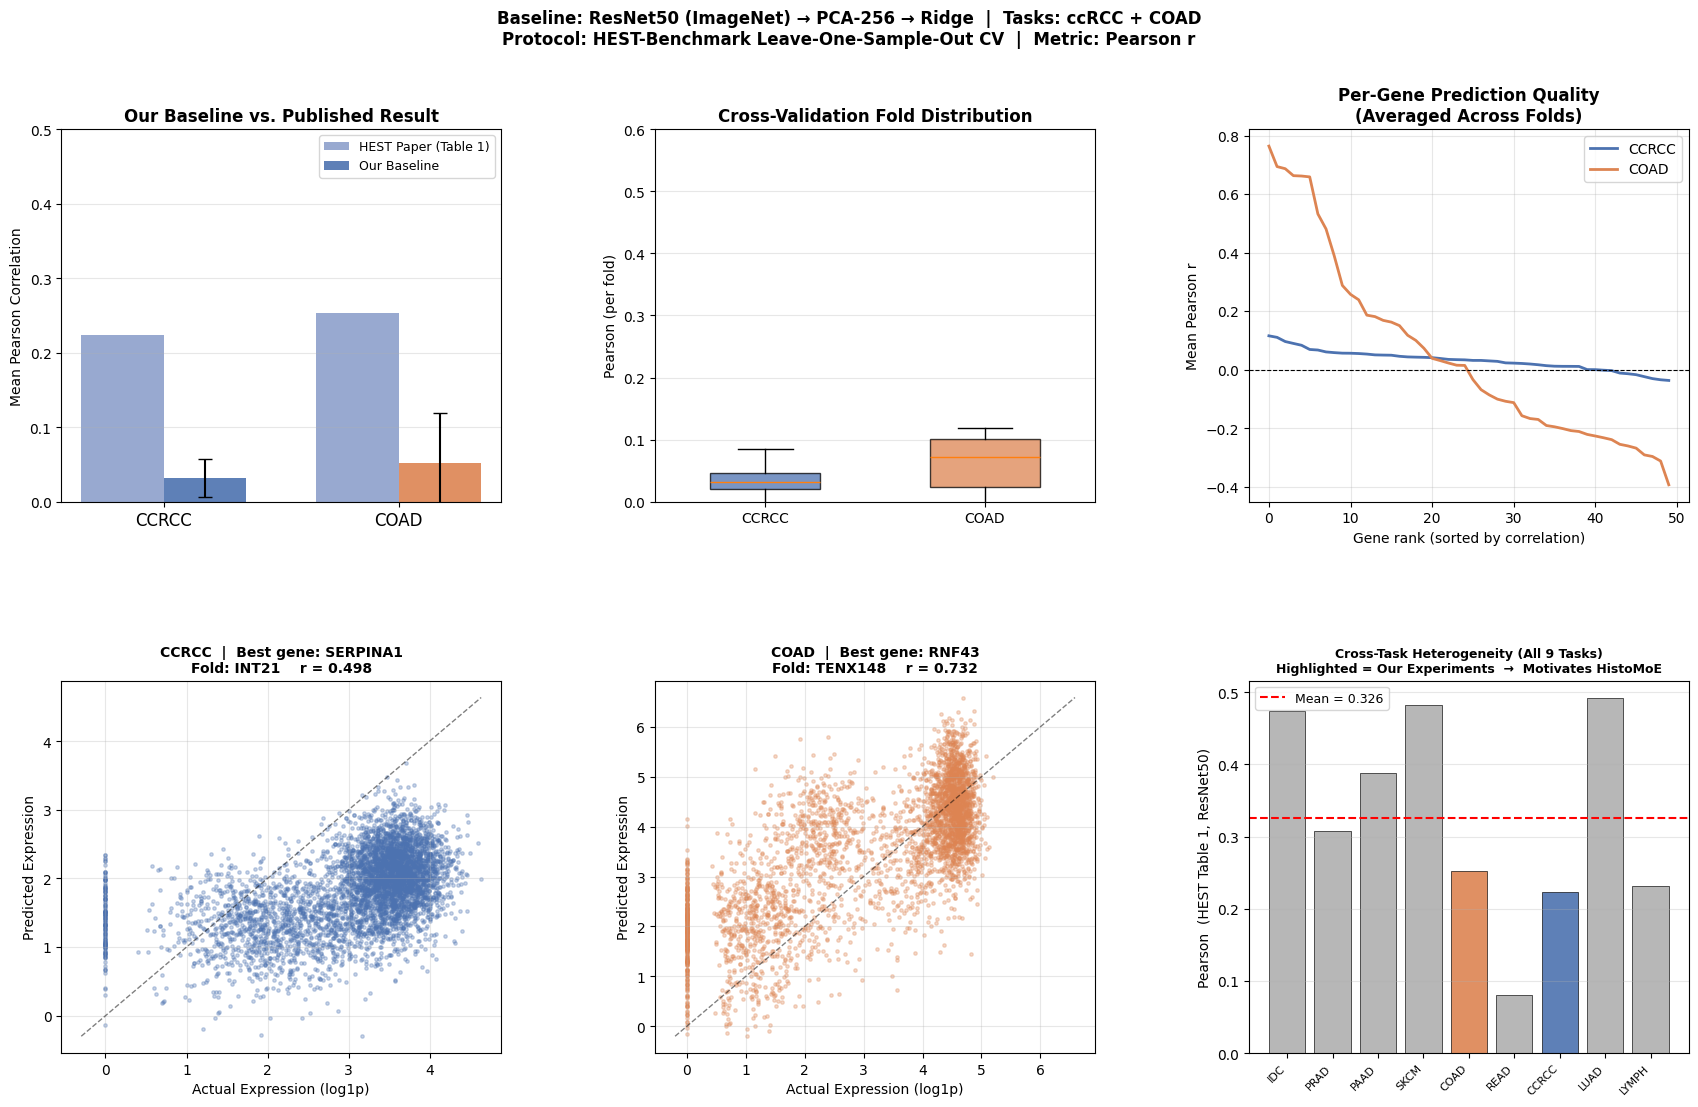


KEY OBSERVATION FOR HistoMoE PROPOSAL:
  CCRCC    mean Pearson: 0.0318
  COAD     mean Pearson: 0.0514
  Performance gap: 0.0196

→ Identical pipeline, very different accuracy across cancer types.
→ so I think HistoMoE expert specialization will directly addresses this gap.


In [13]:
#Visualizations (6 panels)

tasks_with_results = [t for t in TASKS if results.get(t)]

fig = plt.figure(figsize=(21, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)
fig.suptitle(
    'Baseline: ResNet50 (ImageNet) → PCA-256 → Ridge  |  Tasks: ccRCC + COAD\n'
    'Protocol: HEST-Benchmark Leave-One-Sample-Out CV  |  Metric: Pearson r',
    fontsize=12, fontweight='bold'
)

# ── Panel 1: mine vs paper bar chart ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(TASKS)), 0.35
our_means = [summary[t]['mean'] if not np.isnan(summary[t]['mean']) else 0 for t in TASKS]
our_stds  = [summary[t]['std']  if not np.isnan(summary[t]['std'])  else 0 for t in TASKS]
ax1.bar(x - w/2, [PAPER_REF[t] for t in TASKS], w,
        label='HEST Paper (Table 1)', color='#8da0cb', alpha=0.9)
ax1.bar(x + w/2, our_means, w, yerr=our_stds,
        label='Our Baseline', color=[COLORS[t] for t in TASKS],
        alpha=0.9, capsize=5)
ax1.set_xticks(x)
ax1.set_xticklabels(TASKS, fontsize=12)
ax1.set_ylabel('Mean Pearson Correlation')
ax1.set_ylim(0, 0.5)
ax1.set_title('Our Baseline vs. Published Result', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: CV fold distribution boxplot ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
plot_data   = [summary[t]['folds'] for t in TASKS if summary[t]['folds']]
plot_labels = [t for t in TASKS if summary[t]['folds']]
if plot_data:
    bp = ax2.boxplot(plot_data, patch_artist=True, labels=plot_labels, widths=0.5)
    for patch, task in zip(bp['boxes'], plot_labels):
        patch.set_facecolor(COLORS[task])
        patch.set_alpha(0.75)
else:
    ax2.text(0.5, 0.5, 'No results yet', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12)
ax2.set_ylabel('Pearson (per fold)')
ax2.set_ylim(0, 0.6)
ax2.set_title('Cross-Validation Fold Distribution', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: Per-gene Pearson curve (sorted descending) ──────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for task in tasks_with_results:
    all_gc = np.array([v['gene_cors'] for v in results[task].values()])
    # all_gc shape: (n_folds, n_genes) — mean across folds then sort
    mean_per_gene = np.nanmean(all_gc, axis=0)   # shape: (n_genes,)
    ax3.plot(sorted(mean_per_gene.tolist(), reverse=True),
             label=task, color=COLORS[task], lw=2)
ax3.axhline(0, color='black', ls='--', lw=0.8)
ax3.set_xlabel('Gene rank (sorted by correlation)')
ax3.set_ylabel('Mean Pearson r')
ax3.set_title('Per-Gene Prediction Quality\n(Averaged Across Folds)', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)
if not tasks_with_results:
    ax3.text(0.5, 0.5, 'No results yet', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12)

# ── Panels 4 & 5: Scatter predicted vs actual (best fold, best gene) ─────────
for col, task in enumerate(TASKS):
    ax = fig.add_subplot(gs[1, col])
    if not results.get(task):
        ax.text(0.5, 0.5, f'{task}\nNo results yet', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(task, fontweight='bold')
        continue
    best_sid = max(results[task], key=lambda s: results[task][s]['mean'])
    res      = results[task][best_sid]
    best_g   = int(np.argmax(res['gene_cors']))
    gname    = res['gene_names'][best_g] if res['gene_names'] else f'Gene-{best_g}'
    ax.scatter(res['y_test'][:, best_g], res['y_pred'][:, best_g],
               alpha=0.3, s=6, color=COLORS[task], rasterized=True)
    lims = [
        min(res['y_test'][:, best_g].min(), res['y_pred'][:, best_g].min()),
        max(res['y_test'][:, best_g].max(), res['y_pred'][:, best_g].max())
    ]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('Actual Expression (log1p)')
    ax.set_ylabel('Predicted Expression')
    ax.set_title(
        f'{task}  |  Best gene: {gname}\nFold: {best_sid}    r = {res["gene_cors"][best_g]:.3f}',
        fontweight='bold', fontsize=10
    )
    ax.grid(alpha=0.3)

# ── Panel 6: All-9-task heterogeneity from HEST paper ────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
all_tasks  = ['IDC', 'PRAD', 'PAAD', 'SKCM', 'COAD', 'READ', 'CCRCC', 'LUAD', 'LYMPH']
all_scores = [0.4741, 0.3075, 0.3889, 0.4822, 0.2528, 0.0812, 0.2231, 0.4917, 0.2322]
bar_colors = [COLORS.get(t, '#b0b0b0') for t in all_tasks]
ax6.bar(all_tasks, all_scores, color=bar_colors, edgecolor='black', lw=0.5, alpha=0.9)
ax6.axhline(np.mean(all_scores), color='red', ls='--', lw=1.5,
            label=f'Mean = {np.mean(all_scores):.3f}')
ax6.set_xticklabels(all_tasks, rotation=45, ha='right', fontsize=8)
ax6.set_ylabel('Pearson  (HEST Table 1, ResNet50)')
ax6.set_title(
    'Cross-Task Heterogeneity (All 9 Tasks)\n'
    'Highlighted = Our Experiments  →  Motivates HistoMoE',
    fontweight='bold', fontsize=9
)
ax6.legend(fontsize=9)
ax6.grid(axis='y', alpha=0.3)

plt.savefig('histomoe_baseline_results.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n' + '='*60)
print('KEY OBSERVATION FOR HistoMoE PROPOSAL:')
for task in TASKS:
    m = summary[task]['mean']
    print(f'  {task:<8} mean Pearson: {m:.4f}' if not np.isnan(m) else f'  {task:<8} no results')
if both_ok:
    print(f'  Performance gap: {abs(summary["CCRCC"]["mean"]-summary["COAD"]["mean"]):.4f}')
print('\n→ Identical pipeline, very different accuracy across cancer types.')
print('→ so I think HistoMoE expert specialization will directly addresses this gap.')
print('='*60)